In [1]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[0])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
import scipy
import pickle
import sigpy as sp
import cupy as cp
import numpy as np
from scipy.io import savemat, loadmat
import twixtools
import matplotlib.pyplot as plt


## My files
import save_data_helpers
import recon_plot_helpers
import mvf_utils

### Load ADMM results

In [2]:
base_dir = '/data/lilianae/ADMM_results/sweep_20251108_213241/'
iter_num = 7
sweep_dir = 'high_beta_tv_z_rho_0.01_beta_0.005_lam_0.007'

z_abs, lam_abs, tmp_admm, tmp_inv_admm = mvf_utils.load_admm_output(base_dir, iter_num, sweep_dir)

tmp_inv_admm.shape = (5, 58, 512, 512, 3)
tmp_admm.shape = (5, 58, 512, 512, 3)
z_abs.shape = (5, 58, 512, 512)


### Load Optical Flow results

In [3]:
base_dir = '/data/lilianae/ADMM_results/optical_flow/opt_flow_50sp/'
num_gates = 5
img_shape = (58, 512, 512)
indep_recons, tmp_optical_flow, tmp_inv_optical_flow = mvf_utils.load_raw_recons_and_mvfs(base_dir, num_gates=num_gates,
                                                                img_shape=img_shape)

indep_recons.shape = (5, 58, 512, 512)
tmp.shape = (5, 58, 512, 512, 3)
tmp_inv.shape = (5, 58, 512, 512, 3)


### Crop recons + MVFs to desired shape

In [4]:
oshape = (58, 256, 256)

## Motion vectors
cropped_tmp_inv_admm = mvf_utils.crop_gated_mvfs(tmp_inv_admm, oshape)
cropped_tmp_inv_of = mvf_utils.crop_gated_mvfs(tmp_inv_optical_flow, oshape)

## Recons
cropped_recons_admm = mvf_utils.crop_gated_imgs(z_abs, oshape)
cropped_recons_of = mvf_utils.crop_gated_imgs(indep_recons, oshape)

New array shape = (5, 58, 256, 256, 3)
New array shape = (5, 58, 256, 256, 3)
New array shape = (5, 58, 256, 256)
New array shape = (5, 58, 256, 256)


In [5]:
print(cropped_tmp_inv_admm)

[[[[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    ...
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]

   [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    ...
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]

   [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    ...
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]

### Calculate MVF difference between ADMM and Optical Flow

In [6]:
mvf_diff_raw_mm  = mvf_utils.calculate_difference_array(cropped_tmp_inv_admm, cropped_tmp_inv_of)

DEBUGGING STATEMENT:
[[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
  ...
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]

 [[ 5.04523516e-04 -5.72323799e-04  2.83503905e-05]
  [ 3.58223915e-04 -8.79704952e-04  7.42319971e-05]
  [ 1.70961022e-04 -1.26326084e-03  1.27958134e-04]
  ...
  [ 5.05098701e-03 -5.12740612e-02  3.60234082e-03]
  [ 3.11356783e-03 -4.98073101e-02  3.07826698e-03]
  [ 1.28638744e-03 -4.62303162e-02  2.38364935e-03]]

 [[ 9.16913152e-04  6.43074512e-04 -1.15654431e-04]
  [ 7.69615173e-04  3.74495983e-04 -7.67363235e-05]
  [ 5.75363636e-04  1.81198120e-05 -2.96570361e-05]
  ...
  [ 5.69891930e-03 -4.73395586e-02  3.47170234e-03]
  [ 3.89668345e-03 -4.64799404e-02  3.07091326e-03]
  [ 2.22805142e-03 -4.37011719e-02  2.51044333e-03]]

 ...

 [[ 5.4398179

In [7]:
print(mvf_diff_raw_mm.shape)

(5, 58, 256, 256, 3)


In [8]:
metrics = mvf_utils.calculate_mvf_stats(mvf_diff_raw_mm[0,:,:,128,:])
print(metrics)

{'max': 0.32320547103881836, 'max_abs': 0.6223828792572021, 'min': -0.6223828792572021, 'mean_mag': 0.10552330717415855, 'std_mag': 0.06715766955376859}


In [17]:
def plot_recon_with_mvf(gated_imgs, gated_mvfs, gate_idx, slice_axis, slice_idx=None,
                        verbose=True, vector_spacing=10, figsize=(10,15), title="", 
                        text_box=False, textstr=None, metrics=None, color='blue', scale=0.5):
    '''Plot a 2D image slice with motion vectors overlaid
    
    Inputs
    ------------------------------
    gated_imgs : ndarray, (num_gates, nz, ny, nx)
        Gated images
    gated_mvfs : ndarray, (num_gates, nz, ny, nx, ndims)
        MVFs for all gates
    gate_idx : int
        Gate index to view
    slice_axis : int
        2D slice to view 
    slice_idx: int, Optional
        Slice index along slice axis for viewing
    vector_spacing: int, Optional
        Vector spacing for overlaid motion vector field 
    figsize : tuple
        Figure size
    title: str
        First title for plot
    text_box: bool, Optional
        Show textbox with metrics
    metrics: dict, Optional
        keys: 'max', 'min', 'mean_mag', 'std_mag'


    Outputs
    -------------------------------
    fig, axs: matplotlib objects
    
    '''
    fig = plt.figure(figsize=(15, 10))
    # Plot
    ax1 = plt.subplot(131)

    mvf_gate = gated_mvfs[gate_idx] ## 4d
    img_gate = gated_imgs[gate_idx] ## 3d
    Nz, Ny, Nx = img_gate.shape

    ## Get slice_idx if none
    if slice_idx is None:
        slice_idx = img_gate.shape[slice_axis]//2

    if slice_axis==0:
        mvf_slice_2d = mvf_gate[slice_idx, :, :, 1:]
        img_slice_2d = img_gate[slice_idx, :, :]

        mvf_flipped = np.fliplr(mvf_slice_2d)
        mvf_visualization = np.zeros_like(mvf_flipped)
        mvf_visualization[...,0] = mvf_flipped[...,0]
        mvf_visualization[...,1] = -mvf_flipped[...,1]

        ax1.imshow(np.fliplr(img_slice_2d), cmap='gray', aspect=Ny/Nx)

    elif slice_axis==1:
        mvf_slice_2d = mvf_utils.select_array_axes(mvf_gate[:, slice_idx, :, :], axes=(0,2))
        img_slice_2d = img_gate[:, slice_idx, :]

        mvf_rotated = np.rot90(mvf_slice_2d, k=-3)
        mvf_visualization = np.zeros_like(mvf_rotated)
        mvf_visualization[...,0] = mvf_rotated[...,1]
        mvf_visualization[...,1] = -mvf_rotated[...,0]


        ax1.imshow(np.rot90(img_slice_2d, k=-3), cmap='gray', aspect=Nz/Nx)

    elif slice_axis==2:
        mvf_slice_2d = mvf_gate[:, :, slice_idx, :2]
        img_slice_2d = img_gate[:, :, slice_idx]

        mvf_rotated = np.rot90(mvf_slice_2d, k=-1)
        mvf_visualization = np.zeros_like(mvf_rotated)
        print(f'mvf_visualization.shape = {mvf_visualization.shape}')
        mvf_visualization[...,0] = mvf_rotated[...,1]
        mvf_visualization[...,1] = -mvf_rotated[...,0]

        ax1.imshow(np.rot90(img_slice_2d, k=-1), cmap='gray', aspect=Nz/Ny)
    else:
        raise ValueError("slice_axis must be 0, 1, or 2.")

    ## DEBUGGING
    print("DEBUGGING")
    print("="*30)
    vector_magnitudes = np.sqrt(mvf_slice_2d[..., 0]**2 + mvf_slice_2d[..., 1]**2)
    mean_magnitude = np.mean(vector_magnitudes)
    print(f'mean_mag = {mean_magnitude}')


    # Create vector grid
    aspect_ratio = int(np.floor(mvf_visualization.shape[0]/mvf_visualization.shape[1]))
    print(f'aspect_ratio = {aspect_ratio}')


    # Create grid with swapped variable names to match plotting convention
    row_indices, col_indices = np.mgrid[vector_spacing*aspect_ratio:mvf_visualization.shape[0]:vector_spacing*aspect_ratio, 
                                        vector_spacing:mvf_visualization.shape[1]:vector_spacing]

    # Extract vectors
    u = mvf_visualization[row_indices, col_indices, 0]  # horizontal component
    v = mvf_visualization[row_indices, col_indices, 1]  # vertical component

    # Plot with correct coordinate mapping
    ax1.quiver(col_indices, row_indices, u, v, color='blue', angles='xy', 
            scale_units='xy', scale=scale)
    
    ax1.set_title(f'{title}\nZ-Y Motion Vectors\nGate {gate_idx+1}')
    # ax1.axis('off')

    # Add text box on the right side
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    if text_box:
        ax1.text(1.05, 0.5, textstr, transform=ax1.transAxes, fontsize=12,
                verticalalignment='center', bbox=props)

    plt.tight_layout()
    plt.show()

    return fig, ax1

Gate 0 mean magnitude: 3.8721303372127616
Gate 4 mean magnitude: 3.974240063824426
DEBUGGING
mean_mag = 3.6305413072390627
aspect_ratio = 4


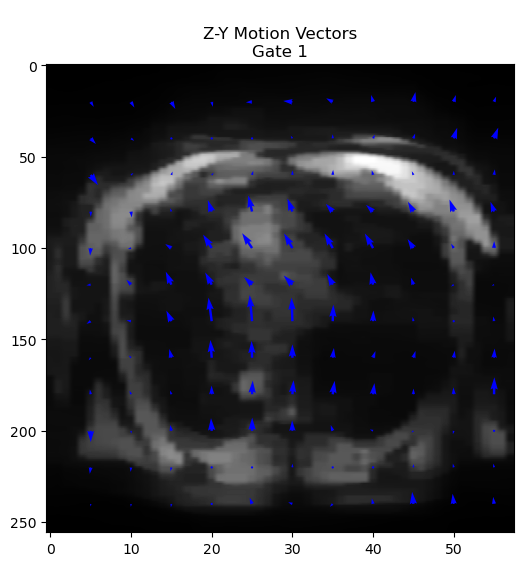

DEBUGGING
mean_mag = 3.563334266760095
aspect_ratio = 4


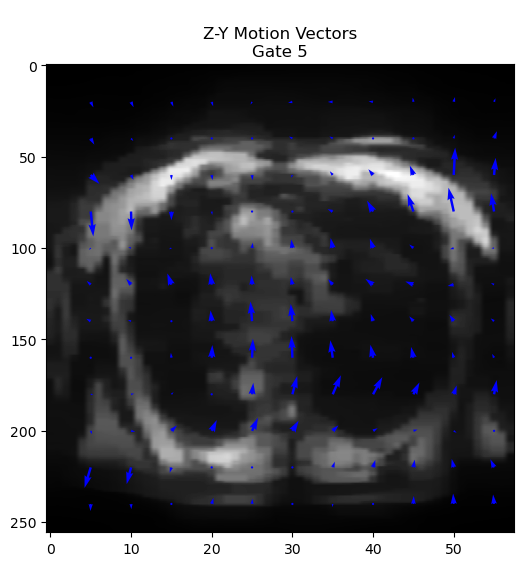

In [19]:
mvf_admm_mm = mvf_utils.convert_mvf_to_mm(cropped_tmp_inv_admm, voxel_spacing=(5, 1.172, 1.172))

print(f"Gate 0 mean magnitude: {np.mean(np.linalg.norm(mvf_admm_mm[0], axis=-1))}")
print(f"Gate 4 mean magnitude: {np.mean(np.linalg.norm(mvf_admm_mm[4], axis=-1))}")

vector_spacing = 5
fig, ax1 = plot_recon_with_mvf(cropped_recons_admm, mvf_admm_mm, gate_idx=0, slice_axis=1, 
                               scale=1.0, vector_spacing=vector_spacing)
fig, ax1 = plot_recon_with_mvf(cropped_recons_admm, mvf_admm_mm, gate_idx=4, slice_axis=1, 
                               scale=1.0, vector_spacing=vector_spacing)

DEBUGGING
mean_mag = 1.3670140160665085
aspect_ratio = 1


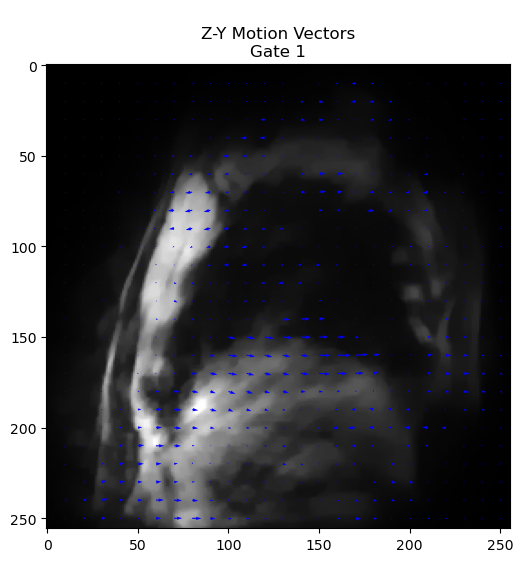

DEBUGGING
mean_mag = 1.3611540876956878
aspect_ratio = 1


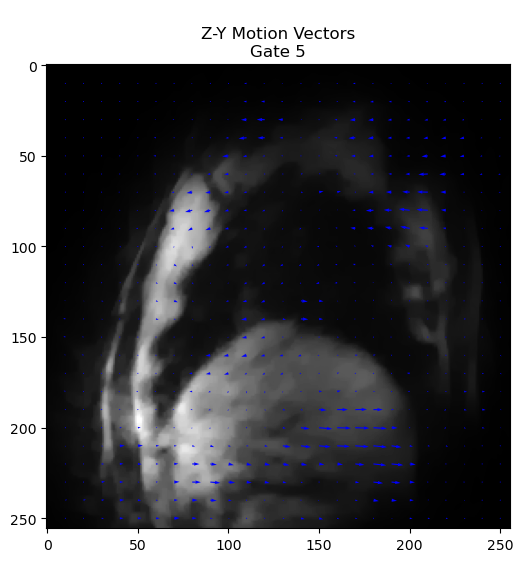

In [23]:
vector_spacing=10
fig, ax1 = plot_recon_with_mvf(cropped_recons_admm, mvf_admm_mm, gate_idx=0, slice_axis=0, slice_idx=44,
                               scale=1.0, vector_spacing=vector_spacing)
fig, ax1 = plot_recon_with_mvf(cropped_recons_admm, mvf_admm_mm, gate_idx=4, slice_axis=0, slice_idx=44, 
                               scale=1.0, vector_spacing=vector_spacing)

mvf_visualization.shape = (256, 58, 2)
DEBUGGING
mean_mag = 4.297407351757384
aspect_ratio = 4


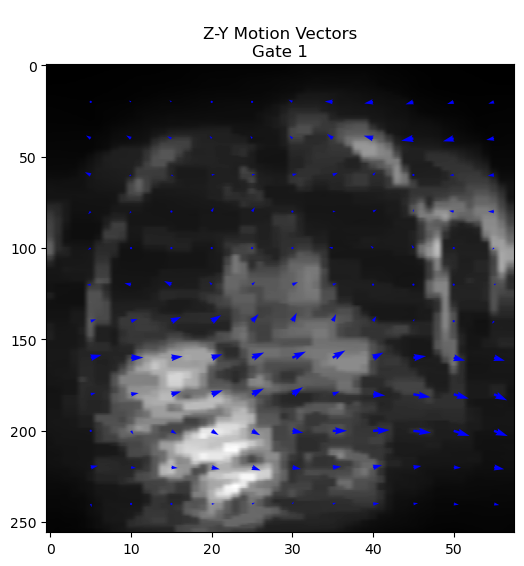

mvf_visualization.shape = (256, 58, 2)
DEBUGGING
mean_mag = 4.640218118569881
aspect_ratio = 4


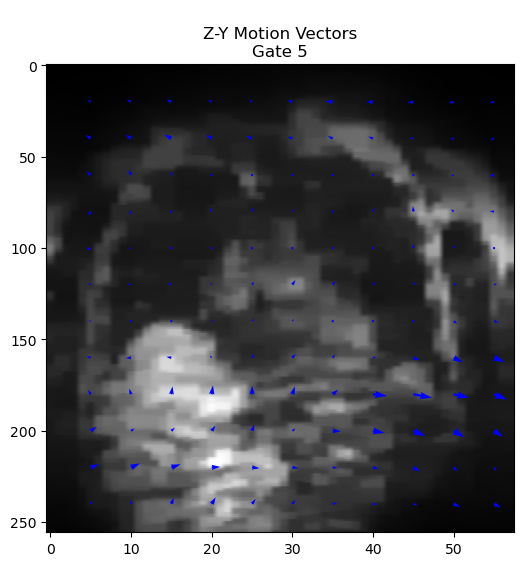

In [25]:
vector_spacing=5
fig, ax1 = plot_recon_with_mvf(cropped_recons_admm, mvf_admm_mm, gate_idx=0, slice_axis=2,
                               scale=3.0, vector_spacing=vector_spacing)
fig, ax1 = plot_recon_with_mvf(cropped_recons_admm, mvf_admm_mm, gate_idx=4, slice_axis=2,
                               scale=3.0, vector_spacing=vector_spacing)